<a href="https://colab.research.google.com/github/A-J-5/AntonyJuma--portfolio/blob/main/Template_SUN_DS_Sept_Work_Day3_Session3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#These are libraries that you should import if needed for your notebook.
#import libraries
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Product defects ##

A manufacturing plant produces a specific product, and defects can be categorized into four types. Based on historical data, the company expects the following distribution of defect types:

50% of the products are expected to be defect-free.

20% of the products are expected to have Type A defects.

15% of the products are expected to have Type B defects.

15% of the products are expected to have Type C defects.




The company inspects 400 products, and the observed distribution of defect types is:

250 products were defect-free.

50 products had Type A defects.

40 products had Type B defects.

60 products had Type C defects.

In [ ]:
#Let's create a table
defects = pd.DataFrame({"Type": ["No", "A", "B", "C"]})
defects

,Type
0,No
1,A
2,B
3,C


In [ ]:
#Let's add more columns
defects["past"] = [0.5, 0.2, 0.15, 0.15]
defects["Observed"] = [250/400, 50/400, 40/400, 60/400]
defects

,Type,past,Observed
0,No,0.50,0.625
1,A,0.20,0.125
2,B,0.15,0.100
3,C,0.15,0.150


[Text(0, 0, 'No'), Text(0, 1, 'A'), Text(0, 2, 'B'), Text(0, 3, 'C')]

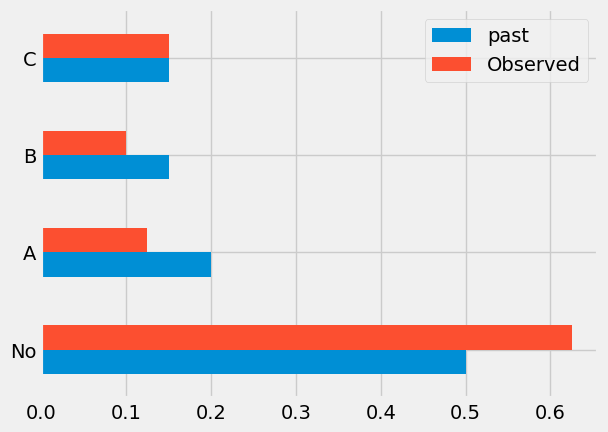

In [ ]:
#plot
defects.plot(kind = "barh").set_yticklabels(defects["Type"])

In [ ]:
# Under the model, this is the true distribution of defects
# from which products are randomly sampled
outcomes =["No", "A", "B", "C"]
model = [0.5, 0.2, 0.15, 0.15]

In [ ]:
#let's determine the percentage of each outome from the model distribution
simulated = np.random.choice(outcomes, p=model, size=400)

result = []
for i in outcomes:
  result.append(sum(simulated==i)/400)

result

[np.float64(0.495), np.float64(0.195), np.float64(0.175), np.float64(0.135)]

In [ ]:
# Let's simulate a random draw of 400 products from the model distribution
def sample():
  simulated = np.random.choice(outcomes, p=model, size=400)
  result = []
  for i in outcomes:
    result.append(sum(simulated==i)/400)

  return result

In [ ]:
sample()

[np.float64(0.4825), np.float64(0.195), np.float64(0.1725), np.float64(0.15)]

In [ ]:
# Let's put this into a table
defects_with_simulated = defects.copy()
defects_with_simulated['Simulated'] = sample()
defects_with_simulated

,Type,past,Observed,Simulated
0,No,0.50,0.625,0.4375
1,A,0.20,0.125,0.2300
2,B,0.15,0.100,0.1675
3,C,0.15,0.150,0.1650


[Text(0, 0, 'No'), Text(0, 1, 'A'), Text(0, 2, 'B'), Text(0, 3, 'C')]

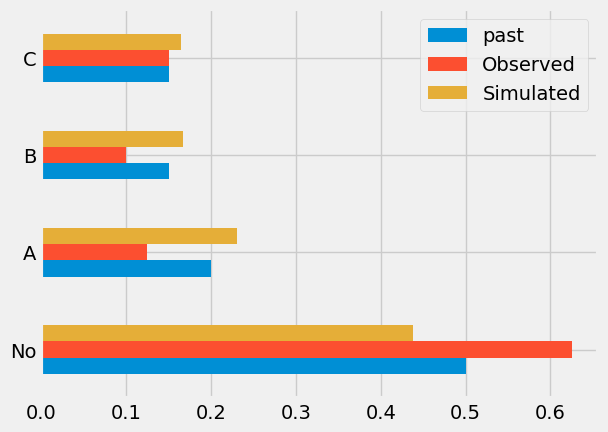

In [ ]:
#Let's plot this
defects_with_simulated.plot(kind = "barh").set_yticklabels(defects["Type"])

## Distance Between Distributions

In [ ]:
# We need to understand how each of the 4 categories
# differ from their expected values according to the model.
def tvd(dist1,dist2):
  return sum(abs(dist1-dist2))/2

## Total Variation Distance

In [ ]:
#Let's define total variation distance
def tvd(dist1,dist2):
    return sum(abs(dist1 - dist2))/2

In [ ]:
# The TVD of our observed data (observed) from their expected values
# assuming the model is true (past)
obsvd_tvd= tvd(defects["past"],defects["Observed"])
obsvd_tvd

0.125

In [ ]:
# The TVD of a model simluation from its expected values
tvd(sample(),defects["past"])

0.03749999999999999

In [ ]:
#Let's put this into a function
def simulated_tvd():
  return tvd(sample(),defects['past'])


tvds = []

num_simulation =1000
for i in np.arange(num_simulation):
  tvds.append(simulated_tvd())

In [ ]:
tvds

[0.024999999999999967,
 0.02500000000000001,
 0.02500000000000001,
 0.017500000000000016,
 0.02250000000000002,
 0.007500000000000007,
 0.020000000000000018,
 0.06250000000000001,
 0.024999999999999994,
 0.04500000000000001,
 0.035,
 0.029999999999999985,
 0.03499999999999999,
 0.020000000000000004,
 0.049999999999999996,
 0.02999999999999997,
 0.035,
 0.05500000000000001,
 0.03249999999999999,
 0.03999999999999998,
 0.03999999999999998,
 0.012500000000000011,
 0.037500000000000006,
 0.0475,
 0.012499999999999997,
 0.02249999999999998,
 0.03,
 0.0325,
 0.02500000000000001,
 0.03749999999999999,
 0.020000000000000004,
 0.05249999999999999,
 0.007499999999999965,
 0.03499999999999999,
 0.03749999999999997,
 0.020000000000000004,
 0.02250000000000002,
 0.030000000000000013,
 0.03499999999999999,
 0.04000000000000001,
 0.022500000000000006,
 0.042499999999999996,
 0.024999999999999994,
 0.04249999999999998,
 0.042499999999999996,
 0.017500000000000016,
 0.03249999999999999,
 0.034999999999

Observed TVD:0.125


(-500.0, 500.0)

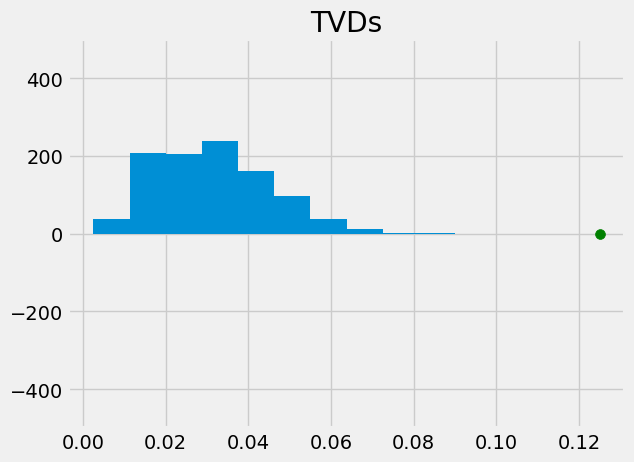

In [ ]:
#Let's plot the results
df = pd.DataFrame({'TVDs': tvds}).hist()
print("Observed TVD:" + str(obsvd_tvd))

plots.scatter(obsvd_tvd,0,color="green",s=50)
plots.ylim(-500,500)